# Prep modelling

In [10]:
# Enable auto-reloading of external modules so you never have to restart the kernel again
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd

# Go up one level to the main FinChat-Analytics folder and add it to the path
sys.path.append(os.path.abspath(os.path.join('..')))

from feature_engineering import CustomerFeatureEngineer
from data.ingestion_pipeline import get_mysql_engine

# 1. Pull data blindly from MySQL and generate the behavioral features!
engineer = CustomerFeatureEngineer()
behavioral_features = engineer.run_feature_engineering()

# 2. Pull the base customer table (we still need the 'churn' label and age)
engine = get_mysql_engine()
customer_df = pd.read_sql_query("""
    SELECT customer_id, age, gender, city, segment_initial, tenure_months, churn 
    FROM customer_data
""", engine)

# 3. Merge them together
df_survival = pd.merge(customer_df, behavioral_features, on='customer_id', how='inner')

INFO:data.ingestion_pipeline:MySQL engine created successfully (pooled)
INFO:feature_engineering:Loaded 80,000 transactions for 5,000 customers
INFO:data.ingestion_pipeline:MySQL engine created successfully (pooled)
INFO:feature_engineering:Feature engineering completed. Shape: (5000, 37)
INFO:data.ingestion_pipeline:MySQL engine created successfully (pooled)


In [22]:
df_survival.head()

,age,tenure_months,churn,frequency,monetary_value,T_months,recency_months,recency_over_T,freq_over_T,freq_30d,...,received_promotion,num_promotions,days_since_last_promotion,gender_Male,city_Hà Nội,city_Hải Phòng,city_TP.HCM,city_Đà Nẵng,segment_initial_Premium,segment_initial_VIP
0,28,29,0,16,166982.06,37.122208,7.490145,0.201592,0.419703,16.0,...,0,0,999.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,47,29,0,19,208095.02,36.235217,7.030223,0.193841,0.510270,19.0,...,0,0,999.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,25,23,0,6,62411.65,33.212878,8.607096,0.258893,0.175373,6.0,...,0,0,999.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,45,26,0,18,205728.75,37.056505,9.034166,0.243578,0.472981,18.0,...,0,0,999.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,26,37,0,14,140000.00,35.085414,9.034166,0.257250,0.387968,14.0,...,1,1,1573.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [13]:
# 1. Drop known non-predictive/ID columns
columns_to_drop = [
    'customer_id', 'tenant_id', 'snapshot_date', 'feature_version', 
    'first_tx', 'last_tx', 'promotion_types'
]
df_survival = df_survival.drop(columns=[col for col in columns_to_drop if col in df_survival.columns])

# 2. Drop Highly Correlated Columns to prevent ConvergenceError
highly_correlated_cols_to_drop = [
    'T',                       # Keep T_months instead
    'recency_days',            # Keep recency_months instead
    'transaction_count_total', # Highly correlated with frequency features
    'active_days'              # Highly correlated with active_days_ratio
]
cols_to_drop = [col for col in highly_correlated_cols_to_drop if col in df_survival.columns]
df_survival = df_survival.drop(columns=cols_to_drop)

# 3. Robust One-Hot Encode (Will not crash if run twice)
cols_to_encode = ['gender', 'city', 'segment_initial']
existing_cols = [col for col in cols_to_encode if col in df_survival.columns]

if existing_cols:
    df_survival = pd.get_dummies(df_survival, columns=existing_cols, drop_first=True, dtype=float)

# 4. Strip any lingering non-numeric columns (like datetime objects) BEFORE doing math
df_survival = df_survival.select_dtypes(include=['number'])

# 5. Drop any Zero-Variance Columns (Failsafe for ConvergenceError)
variances = df_survival.var()
zero_var_cols = variances[variances < 1e-5].index.tolist()
if len(zero_var_cols) > 0:
    print(f"Dropping zero variance columns: {zero_var_cols}")
    df_survival = df_survival.drop(columns=zero_var_cols)

print(f"Ready for modeling! Final shape: {df_survival.shape}")

Dropping zero variance columns: ['monetary_ratio', 'min_tx_value']
Ready for modeling! Final shape: (5000, 31)


In [ ]:
# !pip install lifelines

In [14]:
from lifelines import CoxPHFitter

# Initialize the Cox model
cph = CoxPHFitter(penalizer=0.1) # Added a small penalizer to help with multicollinearity stability during training

# Fit the model: T = duration (tenure), E = event (churn)
cph.fit(
    df_survival, 
    duration_col='tenure_months', 
    event_col='churn',
    show_progress=True
)

# Print out the statistical summary (the "Weights", P-values, Hazard Ratios)
cph.print_summary()


Iteration 1: norm_delta = 4.74e-01, step_size = 0.9500, log_lik = -5360.09042, newton_decrement = 1.31e+02, seconds_since_start = 0.0
Iteration 2: norm_delta = 3.27e-02, step_size = 0.9500, log_lik = -5228.01835, newton_decrement = 6.02e-01, seconds_since_start = 0.0
Iteration 3: norm_delta = 1.71e-03, step_size = 0.9500, log_lik = -5227.41662, newton_decrement = 1.66e-03, seconds_since_start = 0.0
Iteration 4: norm_delta = 2.65e-07, step_size = 1.0000, log_lik = -5227.41496, newton_decrement = 5.76e-11, seconds_since_start = 0.0
Convergence success after 4 iterations.


<lifelines.CoxPHFitter: fitted with 5000 total observations, 4332 right-censored observations>
             duration col = 'tenure_months'
                event col = 'churn'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 5000
number of events observed = 668
   partial log-likelihood = -5227.41
         time fit was run = 2026-04-23 09:30:01 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
age                       -0.06      0.94      0.00           -0.07           -0.05                0.93                0.95
frequency                 -0.00      1.00      0.01           -0.02            0.02                0.98                1.02
monetary_value             0.00      1.00      0.00           -0.00            0.00                1.00                1.00
T_months                   0.01      1.01      0.02           -0.02            0.04                0.98                1.04
recency_months             0.01      1.01      0.02           -0.03            0.04                0.97                1.04
recency_over_T             0.23      1.26      0.63           -1.00            1.46                0.37                4.32
freq_over_T               -0.10      0.91      0.42           -0.92            0.73                0.40                2.08
freq_30d                  -0.00      1.00      0.01           -0.02            0.02                0.98                1.02
monetary_30d               0.00      1.00      0.00           -0.00            0.00                1.00                1.00
freq_90d                  -0.00      1.00      0.01           -0.02            0.02                0.98                1.02
monetary_90d               0.00      1.00      0.00           -0.00            0.00                1.00                1.00
freq_180d                 -0.00      1.00      0.01           -0.02            0.02                0.98                1.02
monetary_180d              0.00      1.00      0.00           -0.00            0.00                1.00                1.00
freq_ratio                 0.37      1.44      2.42           -4.37            5.10                0.01              164.53
avg_days_between          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
std_days_between           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
avg_tx_value               0.00      1.00      0.00           -0.00            0.00                1.00                1.00
max_tx_value               0.00      1.00      0.00           -0.00            0.00                1.00                1.00
active_days_ratio          0.50      1.65      1.38           -2.20            3.20                0.11               24.59
received_promotion        -0.04      0.96      0.08           -0.19            0.11                0.82                1.12
num_promotions            -0.04      0.96      0.08           -0.19            0.11                0.82                1.12
days_since_last_promotion  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
gender_Male               -0.05      0.95      0.06           -0.16            0.07                0.85                1.07
city_Hà Nội                0.03      1.03      0.07           -0.11            0.16                0.90                1.18
city_Hải Phòng             0.03      1.03      0.10           -0.17            0.23                0.85                1.25
city_TP.HCM               -0.03      0.97      0.07           -0.16            0.10                0.85                1.11
city_Đà Nẵng              -0.00      1.00      0.09           -0.17            0.17           

In [21]:
weights_df = cph.summary[['coef', 'exp(coef)', 'p']]
print(weights_df)

                                   coef  exp(coef)             p
covariate                                                       
age                       -6.082769e-02   0.940985  1.037250e-56
frequency                 -1.366725e-03   0.998634  8.983706e-01
monetary_value             9.133479e-08   1.000000  9.056448e-01
T_months                   9.817511e-03   1.009866  5.180369e-01
recency_months             7.712622e-03   1.007742  6.499332e-01
recency_over_T             2.322411e-01   1.261424  7.117871e-01
freq_over_T               -9.639617e-02   0.908104  8.193043e-01
freq_30d                  -1.706936e-03   0.998295  8.716895e-01
monetary_30d               8.228144e-08   1.000000  9.150160e-01
freq_90d                  -1.532505e-03   0.998469  8.845913e-01
monetary_90d               9.133479e-08   1.000000  9.056448e-01
freq_180d                 -1.532505e-03   0.998469  8.845913e-01
monetary_180d              9.133479e-08   1.000000  9.056448e-01
freq_ratio               

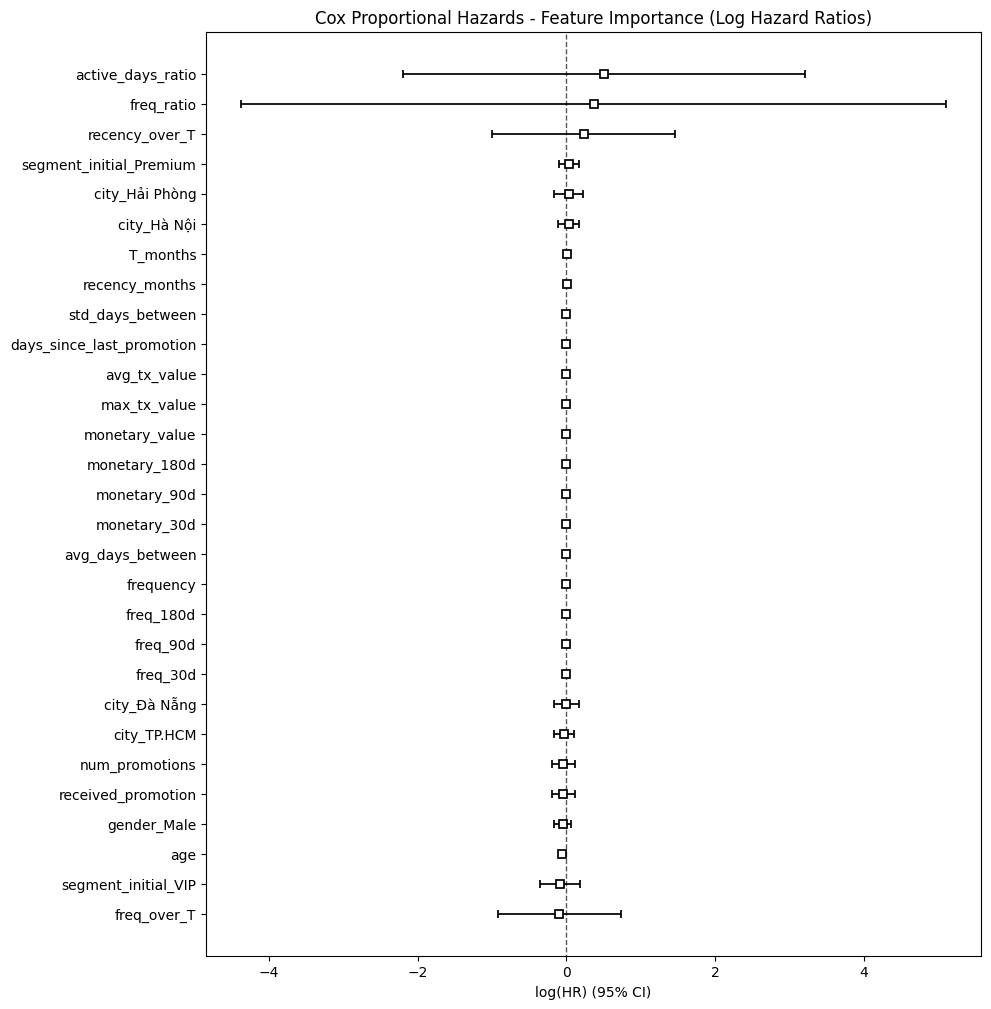

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
cph.plot()
plt.title("Cox Proportional Hazards - Feature Importance (Log Hazard Ratios)")
plt.show()


In [17]:
# Filter out customers who haven't churned yet
active_customers = df_survival[df_survival['churn'] == 0].copy()

# Predict how long until they churn
predictions = cph.predict_median(active_customers)

# Predict survival probability at month 12
survival_prob_12m = cph.predict_survival_function(active_customers, times=[12])

print("Expected Lifetime Predictions Generated!")


Expected Lifetime Predictions Generated!


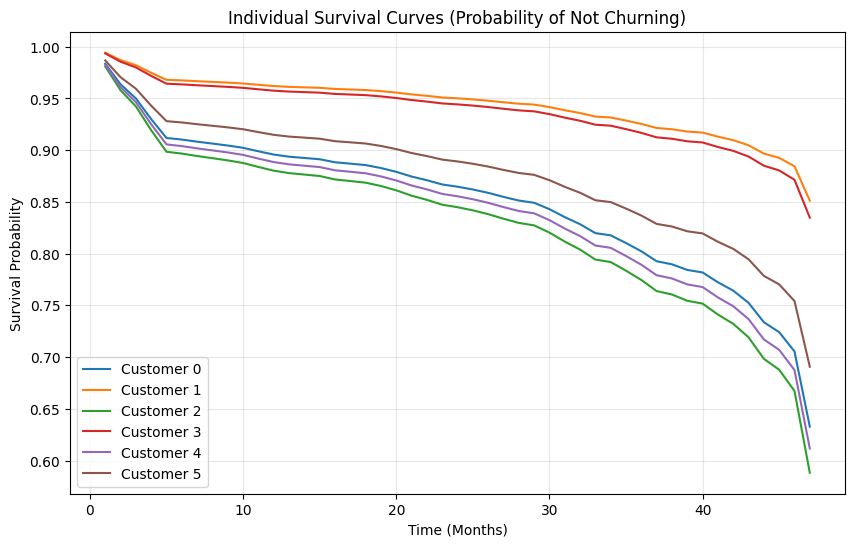

Individual survival curves plotted for a sample of customers.


In [19]:
# 1. Select a small sample of active customers to visualize
sample_customers = active_customers.head(6) 

# 2. Predict the survival function (probability over time) for these individuals
# This returns a DataFrame where rows are time points and columns are customers
individual_survival_curves = cph.predict_survival_function(sample_customers)

# 3. Plotting the individual curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(individual_survival_curves)

plt.title("Individual Survival Curves (Probability of Not Churning)")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.legend([f"Customer {i}" for i in sample_customers.index], loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

print("Individual survival curves plotted for a sample of customers.")